# ControlNet

**ControlNet** is an adapter that enables controllable generation such as generating an image of a cat in a specific pose or following the lines in a sketch of a specific cat. It works by adding a smaller network of “zero convolution” layers and progressively training these to avoid disrupting with the original model. The original model parameters are frozen to avoid retraining it.

A ControlNet is conditioned on extra visual information or “structural controls” (canny edge, depth maps, human pose, etc.) that can be combined with text prompts to generate images that are guided by the visual input.

## Check requirements

Before running computationally expensive models like ControlNet, it is essential to verify that a GPU is active.

**Why it matters**: Deep learning relies on massive parallel processing. A GPU can execute these operations up to 100x faster than a standard CPU.

**The Check**: We use torch.cuda.is_available() to ensure the notebook is connected to a hosted hardware accelerator.

**Action Required**: If the cell below returns False, go to Runtime > Change runtime type and select T4 GPU (or any available GPU) to speed up your generations.

In [ ]:
import torch

# Check if CUDA (NVIDIA GPU support) is available
if torch.cuda.is_available():
    print(f"GPU is available: {torch.cuda.get_device_name(0)}")
else:
    print("GPU not found. Running on CPU (this will be slow).")

GPU not found. Running on CPU (this will be slow).


## Import image

Generate a **canny image** with opencv-python. It'll be passed into the model to **add conditions** to control the generation of the image.

In [ ]:
import cv2
import numpy as np
from PIL import Image
from diffusers.utils import load_image

original_image = load_image(
    "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/non-enhanced-prompt.png"
)

#Convert to numpy array
image = np.array(original_image)

#Parameters of Canny function
low_threshold = 100
high_threshold = 200

#Create the Canny image from the original image
image = cv2.Canny(image, low_threshold, high_threshold)


#Any machine learning models (like Stable Diffusion or ControlNet) expect a 3-channel input.
#This "tricks" the system into treating a grayscale image as a color image.
image = image[:, :, None]
image = np.concatenate([image, image, image], axis=2)
canny_image = Image.fromarray(image)


Shape of the Canny image: (896, 1152, 3)


In [ ]:
print(f"Shape of the Canny image: {np.shape(canny_image)}")

Shape of the Canny image: (896, 1152, 3)


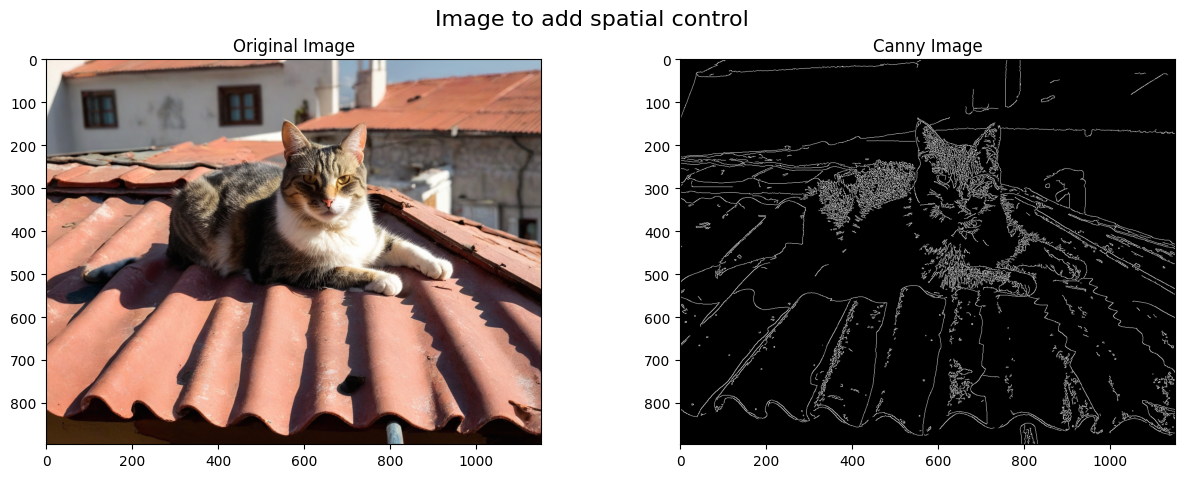

In [ ]:
import matplotlib.pyplot as plt

#Show the images
plt.figure(figsize=(15,5))

plt.suptitle("Image to add spatial control", fontsize=16)
plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(original_image)

plt.subplot(1,2,2)
plt.title("Canny Image")
plt.imshow(canny_image)

## Model

This code sets up a Generative AI pipeline using the Hugging Face diffusers library. Specifically, it uses FLUX.1-dev, a high-quality text-to-image model, augmented with a ControlNet to guide the structure of the generation using an edge map (the canny_image we processed earlier).



ControlNet:
- **FluxControlNetModel** is an implementation of ControlNet for Flux.1
- **InstantX/FLUX.1-dev-Controlnet-Canny** is a specialized adapter designed for the FLUX.1-dev model, one of the most powerful open-weight flow-based transformers available today. By leveraging Canny edge detection, this model allows you to maintain strict structural integrity over your generations


Pipeline:
- **FluxControlNetPipeline** is the Flux pipeline for text-to-image generation. It is the dedicated class within the Hugging Face diffusers library designed to run the FLUX.1 model guided by a ControlNet.
- **black-forest-labs/FLUX.1-dev** is a 12 billion parameter rectified flow transformer capable of generating images from text descriptions.



In [ ]:
from diffusers.utils import load_image
from diffusers import FluxControlNetPipeline, FluxControlNetModel

controlnet = FluxControlNetModel.from_pretrained(
    "InstantX/FLUX.1-dev-Controlnet-Canny", torch_dtype=torch.bfloat16
)
pipeline = FluxControlNetPipeline.from_pretrained(
    "black-forest-labs/FLUX.1-dev", controlnet=controlnet, torch_dtype=torch.bfloat16
)

prompt = """
A photorealistic overhead image of a cat reclining sideways in a flamingo pool floatie holding a margarita.
The cat is floating leisurely in the pool and completely relaxed and happy.
"""

**Memory Optimization**: CPU Offloading Strategies
To run heavy models like FLUX.1-dev on consumer hardware, we use Offloading. This technique drastically reduces VRAM usage by dynamically moving parts of the pipeline between your System RAM and GPU VRAM.

Diffusers uses the maxmium memory of all devices by default, but if they don’t fit on the GPUs, then you’ll need to use a single GPU and offload to the CPU with the methods below:
* **enable_model_cpu_offload**: this strategy keeps only the active sub-model (e.g., Text Encoder, ControlNet, or Transformer) in the VRAM at any given time.

  *Example: In a ControlNet pipeline, you have usually 3 models: the text encoder, the ControlNet and the transformer. When you encode the text, only the encoder is on the GPU; afterwards, you move it to the CPU and swap in the ControlNet. Once the ControlNet forward pass is done, you move the transformer in for its forward pass, conditioned by the ControlNet. This way, you only have the weights of a single model in VRAM at any given time (allowing Flux.1-dev to fit).*

* **enable_sequential_cpu_offload**: The most aggressive approach. It breaks down the models even further, moving individual layers to the GPU one by one during the forward pass.

* **enable_group_offload**: a hybrid, customizable approach. It allows you to group specific blocks of the network to stay on the GPU

* **enable_attention_slicing**: enable sliced attention computation. Trading a little speed for lower peak memory during the attention layers.

In [ ]:
# OPTION A: Model-level offloading (recommended starting point)
# Moves whole sub-models (VAE, encoder, transformer) to GPU only when needed.
# Requires ~16GB VRAM. Moderate slowdown (~10-20%).
pipeline.enable_model_cpu_offload()

# OPTION B: Sequential (layer-level) offloading (most aggressive)
# Moves individual layers to GPU one at a time.
# Can run on ~8GB VRAM, but significantly slower.
# pipeline.enable_sequential_cpu_offload()


Pipeline description:
- **prompt**: the prompt or prompts to guide the image generation
- **control_image**: The ControlNet input condition to provide guidance for generation. Pass the canny image to the pipeline
- **controlnet_conditioning_scale**: to determine how much weight to assign to the control.The outputs of the ControlNet are multiplied by controlnet_conditioning_scale before they are added to the residual in the original model
- **num_inference_steps**: the number of denoising steps. More denoising steps usually lead to a higher quality image at the expense of slower inference.
- **guidance_scale**: higher guidance scale encourages to generate images that are closely linked to the text prompt, usually at the expense of lower image quality. Guidance_scale is defined as w of equation 2 of Imagen Paper

In [ ]:
generated_img = pipeline(
    prompt,
    control_image=canny_image,
    controlnet_conditioning_scale=0.5,
    num_inference_steps=50,
    guidance_scale=3.5,
).images[0]


# Display with title
plt.figure(figsize=(8, 8))
plt.title("ControlNet FLUX.1-dev — Generated Image", fontsize=14, fontweight="bold")
plt.imshow(generated_img)
plt.axis("off")
plt.tight_layout()
plt.show()

## Bibliography


- **ControlNet (Diffuser library)**: :https://huggingface.co/docs/diffusers/using-diffusers/controlnet
- **FluxControlNetModel**: https://huggingface.co/docs/diffusers/api/models/controlnet_flux
- **FluxControlNetPipeline**: https://huggingface.co/docs/diffusers/api/pipelines/controlnet_flux#diffusers.FluxControlNetPipeline
- **Optimization memory**: https://huggingface.co/docs/diffusers/optimization/memory